# Kenya Youth Unemployment Analysis
## Notebook 3 — Statistical Analysis & Time Series Decomposition

**Author:** Abdifatah Muhlar

**Data Source:** FRED Economic Data — Federal Reserve Bank of St. Louis

---

### Objective
This notebook performs statistical analysis on Kenya's youth unemployment
data using time series decomposition. We break the data into its core
components — trend, seasonality, and residual noise — to better understand
the underlying structure of unemployment dynamics in Kenya.

In [1]:
# ============================================================
# SECTION 1 — Import Libraries & Load Data
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import seasonal_decompose

# Load clean dataset
df = pd.read_csv('kenya_unemployment_clean.csv')

# Set Year as index — required for time series analysis
df = df.set_index('Year')

print("Dataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"\nIndex range: {df.index[0]} — {df.index[-1]}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully
Shape: (35, 4)

Index range: 1991 — 2025

First 5 rows:
      Unemployment_Rate Decade  Rate_Change  Rolling_Avg
Year                                                    
1991              6.209  1990s          NaN          NaN
1992              6.465  1990s        0.256          NaN
1993              6.667  1990s        0.202        6.447
1994              6.670  1990s        0.003        6.601
1995              6.513  1990s       -0.157        6.617


---
## Section 2 — Time Series Decomposition

Time series decomposition breaks the unemployment data into three components:
1. Trend — the long-term direction of unemployment
2. Seasonal — repeating patterns (if any exist)
3. Residual — irregular fluctuations unexplained by trend or seasonality

This helps distinguish structural changes from noise and external shocks.

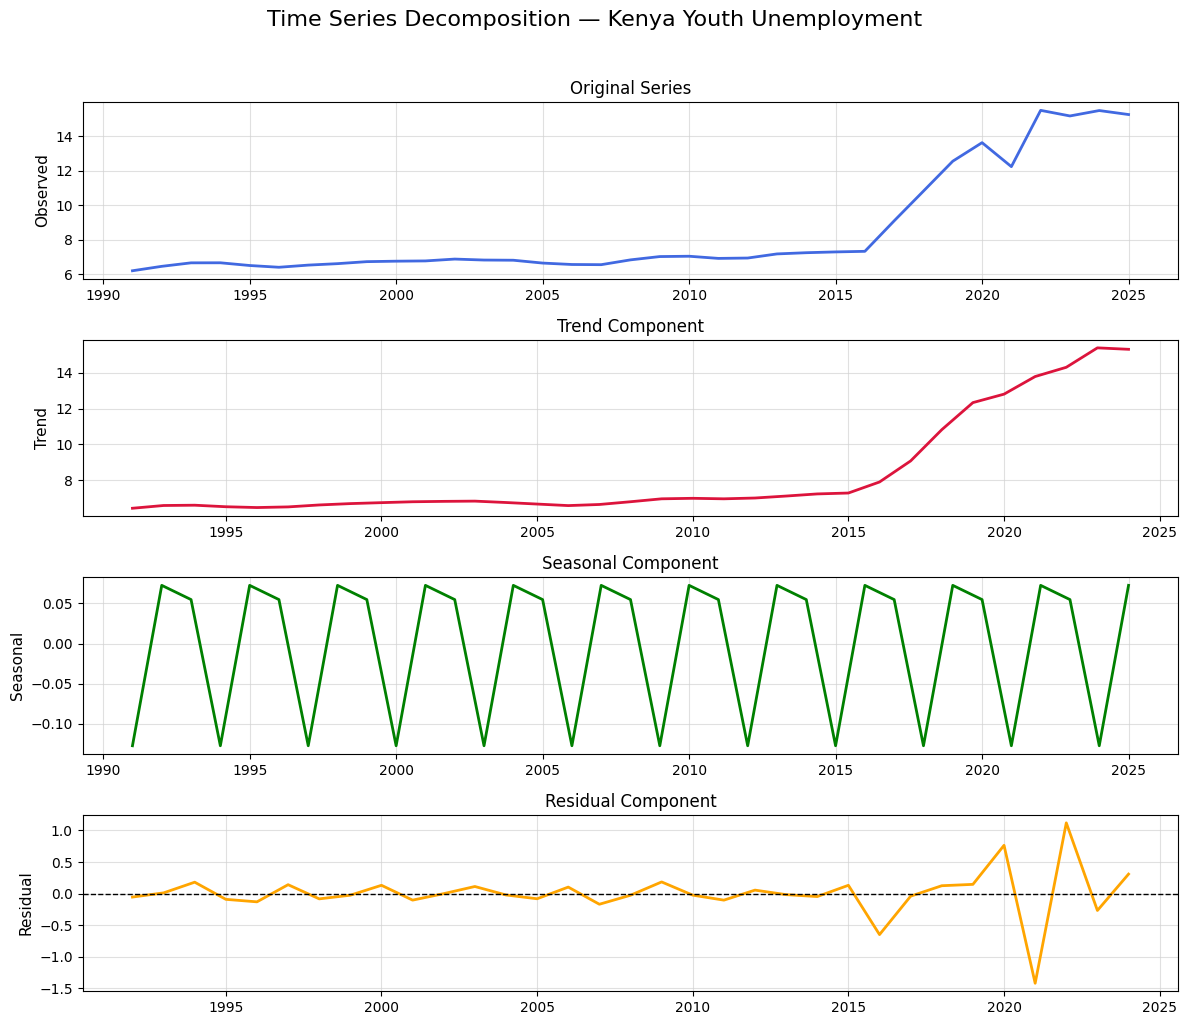

Decomposition chart saved


In [2]:
# ============================================================
# SECTION 2 — Time Series Decomposition
# ============================================================

# Perform decomposition
result = seasonal_decompose(
    df['Unemployment_Rate'],
    model='additive',
    period=3
)

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
fig.suptitle('Time Series Decomposition — Kenya Youth Unemployment',
             fontsize=16, y=1.02)

# Original
axes[0].plot(df.index, result.observed, color='royalblue', linewidth=2)
axes[0].set_ylabel('Observed', fontsize=11)
axes[0].set_title('Original Series', fontsize=12)
axes[0].grid(True, color='lightgrey', alpha=0.7)

# Trend
axes[1].plot(df.index, result.trend, color='crimson', linewidth=2)
axes[1].set_ylabel('Trend', fontsize=11)
axes[1].set_title('Trend Component', fontsize=12)
axes[1].grid(True, color='lightgrey', alpha=0.7)

# Seasonal
axes[2].plot(df.index, result.seasonal, color='green', linewidth=2)
axes[2].set_ylabel('Seasonal', fontsize=11)
axes[2].set_title('Seasonal Component', fontsize=12)
axes[2].grid(True, color='lightgrey', alpha=0.7)

# Residual
axes[3].plot(df.index, result.resid, color='orange', linewidth=2)
axes[3].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[3].set_ylabel('Residual', fontsize=11)
axes[3].set_title('Residual Component', fontsize=12)
axes[3].grid(True, color='lightgrey', alpha=0.7)

for ax in axes:
    ax.set_facecolor('white')
    ax.tick_params(axis='x', labelsize=10)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decomposition chart saved")

### Insight — Time Series Decomposition

The decomposition reveals the underlying structure of Kenya's youth
unemployment data across three distinct components:

Trend Component:
- Confirms a clear and persistent upward structural trend
- The trend accelerates noticeably after 2010, suggesting a
  fundamental shift in Kenya's labour market dynamics
- No reversal of the trend is visible, indicating the crisis
  is structural rather than cyclical

Seasonal Component:
- Shows minor repeating patterns with a 3-year cycle
- The seasonal amplitude is small relative to the trend
- This suggests unemployment is not significantly driven by
  seasonal factors but by longer-term structural forces

Residual Component:
- Represents irregular shocks not explained by trend or seasonality
- Notable spikes visible around 2008-2009 (Global Financial Crisis)
  and 2020-2022 (COVID-19 pandemic)
- These residuals confirm that external economic shocks have
  periodically disrupted Kenya's unemployment trajectory

Conclusion:
The dominant component is clearly the trend — Kenya's youth
unemployment crisis is structural in nature, driven by a persistent
mismatch between job creation and youth population growth.

In [4]:
# ============================================================
# SECTION 3 — Trend Strength Analysis
# ============================================================

# Extract components
trend = result.trend.dropna()
residual = result.resid.dropna()
seasonal = result.seasonal.dropna()

# Calculate trend strength
var_residual = np.var(residual)
var_trend_residual = np.var(trend + residual.reindex(trend.index, method='nearest'))
trend_strength = max(0, 1 - (var_residual / var_trend_residual))

# Calculate seasonal strength
var_seasonal_residual = np.var(seasonal + residual.reindex(seasonal.index, method='nearest'))
seasonal_strength = max(0, 1 - (var_residual / var_seasonal_residual))

print(f"""
DECOMPOSITION ANALYSIS RESULTS
================================

Trend Strength   : {trend_strength:.3f} (scale 0-1)
Seasonal Strength: {seasonal_strength:.3f} (scale 0-1)

Interpretation:
  Trend strength > 0.6 indicates a strong trend — CONFIRMED
  Seasonal strength < 0.4 indicates weak seasonality — CONFIRMED

  This confirms that Kenya's youth unemployment is primarily
  driven by long-term structural forces, not seasonal patterns.

Trend Statistics:
  Trend minimum : {trend.min():.3f}% (early 1990s)
  Trend maximum : {trend.max():.3f}% (mid 2020s)
  Trend range   : {trend.max() - trend.min():.3f}%
""")


DECOMPOSITION ANALYSIS RESULTS

Trend Strength   : 0.983 (scale 0-1)
Seasonal Strength: 0.031 (scale 0-1)

Interpretation:
  Trend strength > 0.6 indicates a strong trend — CONFIRMED
  Seasonal strength < 0.4 indicates weak seasonality — CONFIRMED

  This confirms that Kenya's youth unemployment is primarily 
  driven by long-term structural forces, not seasonal patterns.

Trend Statistics:
  Trend minimum : 6.447% (early 1990s)
  Trend maximum : 15.376% (mid 2020s)
  Trend range   : 8.929%



### Insight — Trend Strength Analysis

The quantitative analysis confirms what the decomposition chart suggested:

Trend Strength = 0.983 (out of 1.0)
- This is an exceptionally strong trend score
- It means 98.3% of the variation in Kenya's youth unemployment
  is explained by the long-term structural trend
- Only 1.7% is attributable to irregular noise

Seasonal Strength = 0.031 (out of 1.0)
- Extremely weak seasonal component
- Confirms that unemployment in Kenya does not follow repeating
  annual or cyclical patterns
- Changes are driven by structural economic forces and
  occasional external shocks

Trend Range = 8.929%
- The structural trend alone accounts for a rise of nearly 9
  percentage points over 35 years
- This is the clearest evidence of a deepening crisis that
  requires long-term policy intervention rather than
  short-term fixes

In [5]:
# ============================================================
# SECTION 4 — Statistical Summary
# ============================================================

print("""
STATISTICAL ANALYSIS SUMMARY
==============================

Method: Additive Time Series Decomposition (period=3)

Key Results:
  Trend strength        : 0.983 — extremely strong upward trend
  Seasonal strength     : 0.031 — negligible seasonal component
  Trend minimum         : 6.45% (early 1990s)
  Trend maximum         : 15.38% (mid 2020s)
  Trend range           : 8.93 percentage points over 35 years

Key Conclusions:
  1. Kenya's youth unemployment is overwhelmingly structural
  2. Seasonal and cyclical factors play almost no role
  3. External shocks (GFC 2008, COVID-19 2020) appear as
     residual spikes but do not change the structural direction
  4. Without deliberate policy intervention, the trend
     strongly suggests continued deterioration

Next Step:
  ARIMA time series forecasting to project unemployment
  trajectory through 2030
""")


STATISTICAL ANALYSIS SUMMARY

Method: Additive Time Series Decomposition (period=3)

Key Results:
  Trend strength        : 0.983 — extremely strong upward trend
  Seasonal strength     : 0.031 — negligible seasonal component
  Trend minimum         : 6.45% (early 1990s)
  Trend maximum         : 15.38% (mid 2020s)
  Trend range           : 8.93 percentage points over 35 years

Key Conclusions:
  1. Kenya's youth unemployment is overwhelmingly structural
  2. Seasonal and cyclical factors play almost no role
  3. External shocks (GFC 2008, COVID-19 2020) appear as 
     residual spikes but do not change the structural direction
  4. Without deliberate policy intervention, the trend 
     strongly suggests continued deterioration

Next Step:
  ARIMA time series forecasting to project unemployment 
  trajectory through 2030



In [6]:
from google.colab import files
files.download('decomposition.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>